# Historia FP-Growth


FP-Growth fue presentado en el año 2000 por:

Jiawei Han
Jian Pei
Yin Lu


Artículo:

"Mining Frequent Patterns without Candidate Generation"


El algoritmo fue creado como una mejora del algoritmo Apriori.


Problema de Apriori:

Generaba millones de candidatos antes de encontrar patrones.


FP-Growth propone:


Dataset

↓

FP-Tree

↓

Patrones frecuentes

↓

Reglas de asociación


Ventaja principal:

No genera candidatos explícitamente,
lo que reduce considerablemente el costo computacional.

# Objetivos del Proyecto


## Objetivo General


Implementar el algoritmo FP-Growth
para descubrir relaciones frecuentes
entre elementos dentro de un conjunto
de transacciones.


## Objetivos Específicos


✓ Comprender el concepto de minería de datos.


✓ Construir una representación One-Hot.


✓ Obtener conjuntos frecuentes.


✓ Generar reglas de asociación.


✓ Evaluar reglas mediante Support,
Confidence y Lift.

flowchart TD


A[Dataset Transaccional]

B[Preprocesamiento]

C[Codificación One Hot]

D[Construcción FP Tree]

E[Extracción Patrones Frecuentes]

F[Generación Reglas]

G[Evaluación Support Confidence Lift]


A --> B

B --> C

C --> D

D --> E

E --> F

F --> G

In [1]:
# ==========================================================
# Instalación Librerías FP-Growth
# ==========================================================


!pip install mlxtend
# ==========================================================
# Librerías
# ==========================================================


import pandas as pd

import numpy as np


import matplotlib.pyplot as plt


from mlxtend.preprocessing import TransactionEncoder


from mlxtend.frequent_patterns import (
    fpgrowth,
    association_rules
)


print(
    "Librerías cargadas correctamente"
)

Librerías cargadas correctamente


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
# ==========================================================
# Dataset Transaccional
# ==========================================================


transactions = [

['Leche','Pan','Huevos'],

['Pan','Cereal'],

['Leche','Pan'],

['Huevos','Cereal'],

['Leche','Pan','Cereal'],

['Pan','Huevos'],

['Leche','Huevos'],

['Pan','Cereal','Huevos']

]


print(
    "Número de transacciones:",
    len(transactions)
)

Número de transacciones: 8


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [3]:
# ==========================================================
# Mostrar Transacciones
# ==========================================================


df_transactions = pd.DataFrame(
    {
        "Transaccion":
        range(1,len(transactions)+1),

        "Productos":
        transactions
    }
)


display(
    df_transactions
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Transaccion,Productos
0,1,"[Leche, Pan, Huevos]"
1,2,"[Pan, Cereal]"
2,3,"[Leche, Pan]"
3,4,"[Huevos, Cereal]"
4,5,"[Leche, Pan, Cereal]"
5,6,"[Pan, Huevos]"
6,7,"[Leche, Huevos]"
7,8,"[Pan, Cereal, Huevos]"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
# ==========================================================
# One Hot Encoding
# ==========================================================


encoder = TransactionEncoder()


transaction_array = encoder.fit(
    transactions
).transform(
    transactions
)



df_encoded = pd.DataFrame(

    transaction_array,

    columns=encoder.columns_

)



display(
    df_encoded
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Cereal,Huevos,Leche,Pan
0,False,True,True,True
1,True,False,False,True
2,False,False,True,True
3,True,True,False,False
4,True,False,True,True
5,False,True,False,True
6,False,True,True,False
7,True,True,False,True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
# ==========================================================
# Aplicación del Algoritmo FP-Growth
# ==========================================================


frequent_itemsets = fpgrowth(

    df_encoded,

    min_support=0.25,

    use_colnames=True

)



print("="*60)

print("Conjuntos frecuentes encontrados")

print("="*60)


display(
    frequent_itemsets
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Conjuntos frecuentes encontrados


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
0,0.750,(Pan)
1,0.625,(Huevos)
2,0.500,(Leche)
3,0.500,(Cereal)
4,0.375,"(Pan, Huevos)"
5,0.375,"(Pan, Leche)"
6,0.250,"(Leche, Huevos)"
7,0.375,"(Pan, Cereal)"
8,0.250,"(Cereal, Huevos)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
# ==========================================================
# Ordenar Itemsets por Support
# ==========================================================


frequent_itemsets_sorted = (

    frequent_itemsets

    .sort_values(

        by="support",

        ascending=False

    )

)



display(
    frequent_itemsets_sorted
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
0,0.750,(Pan)
1,0.625,(Huevos)
2,0.500,(Leche)
3,0.500,(Cereal)
4,0.375,"(Pan, Huevos)"
5,0.375,"(Pan, Leche)"
7,0.375,"(Pan, Cereal)"
6,0.250,"(Leche, Huevos)"
8,0.250,"(Cereal, Huevos)"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# ==========================================================
# Crear reglas de asociación
# ==========================================================


rules = association_rules(

    frequent_itemsets,

    metric="confidence",

    min_threshold=0.5

)



display(
    rules
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Pan),(Huevos),0.750,0.625,0.375,0.50,0.8,1.0,-0.09375,0.750,-0.500000,0.375000,-0.333333,0.550
1,(Huevos),(Pan),0.625,0.750,0.375,0.60,0.8,1.0,-0.09375,0.625,-0.400000,0.375000,-0.600000,0.550
2,(Pan),(Leche),0.750,0.500,0.375,0.50,1.0,1.0,0.00000,1.000,0.000000,0.428571,0.000000,0.625
3,(Leche),(Pan),0.500,0.750,0.375,0.75,1.0,1.0,0.00000,1.000,0.000000,0.428571,0.000000,0.625
4,(Leche),(Huevos),0.500,0.625,0.250,0.50,0.8,1.0,-0.06250,0.750,-0.333333,0.285714,-0.333333,0.450
5,(Pan),(Cereal),0.750,0.500,0.375,0.50,1.0,1.0,0.00000,1.000,0.000000,0.428571,0.000000,0.625
6,(Cereal),(Pan),0.500,0.750,0.375,0.75,1.0,1.0,0.00000,1.000,0.000000,0.428571,0.000000,0.625
7,(Cereal),(Huevos),0.500,0.625,0.250,0.50,0.8,1.0,-0.06250,0.750,-0.333333,0.285714,-0.333333,0.450


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [8]:
# ==========================================================
# Selección de métricas importantes
# ==========================================================


rules_result = rules[

    [

    "antecedents",

    "consequents",

    "support",

    "confidence",

    "lift"

    ]

]


display(
    rules_result
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,support,confidence,lift
0,(Pan),(Huevos),0.375,0.50,0.8
1,(Huevos),(Pan),0.375,0.60,0.8
2,(Pan),(Leche),0.375,0.50,1.0
3,(Leche),(Pan),0.375,0.75,1.0
4,(Leche),(Huevos),0.250,0.50,0.8
5,(Pan),(Cereal),0.375,0.50,1.0
6,(Cereal),(Pan),0.375,0.75,1.0
7,(Cereal),(Huevos),0.250,0.50,0.8


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

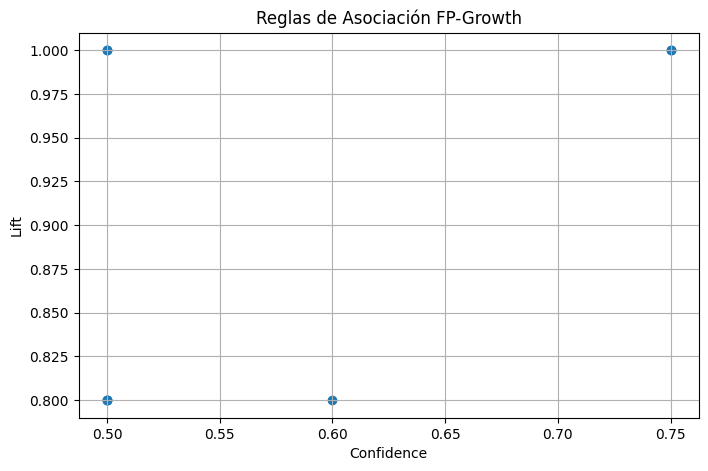

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
# ==========================================================
# Visualización Confidence vs Lift
# ==========================================================


plt.figure(
    figsize=(8,5)
)


plt.scatter(

    rules["confidence"],

    rules["lift"]

)



plt.xlabel(
    "Confidence"
)


plt.ylabel(
    "Lift"
)


plt.title(
    "Reglas de Asociación FP-Growth"
)


plt.grid()


plt.show()

flowchart TD


A[Transacciones]


B[Ordenar Items por frecuencia]


C[Crear Nodo Raíz]


D[Insertar elementos]


E[FP Tree]


F[Patrones frecuentes]


A --> B

B --> C

C --> D

D --> E

E --> F

In [10]:
# ==========================================================
# Ejemplo Support Manual
# ==========================================================


total_transactions = len(transactions)


pan_count = 0



for t in transactions:

    if "Pan" in t:

        pan_count += 1



support_pan = (

    pan_count

    /

    total_transactions

)



print(
    "Support Pan:",
    support_pan
)

Support Pan: 0.75


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Comparación de Algoritmos


|Característica|Apriori|FP-Growth|
|-|-|-|
|Generación candidatos|Sí|No|
|Estructura|Conjuntos|FP-Tree|
|Velocidad|Menor|Mayor|
|Memoria|Alta|Optimizada|
|Escalabilidad|Media|Alta|


FP-Growth es una evolución de Apriori.

# Conclusiones


FP-Growth permite descubrir patrones
frecuentes dentro de grandes conjuntos
de transacciones.


Ventajas:


✓ No genera candidatos.

✓ Usa estructura FP-Tree.

✓ Mayor velocidad que Apriori.

✓ Escalable para grandes datasets.


Aplicaciones:


- Sistemas recomendadores.

- Market Basket Analysis.

- Comercio electrónico.

- Análisis de comportamiento cliente.

- Marketing personalizado.


Limitaciones:


- Necesita definir Support adecuado.

- Puede generar muchas reglas.

- Interpretación requiere análisis.

# Proyecto FP-Growth Algorithm


## Objetivo


Implementar minería de reglas de asociación
mediante el algoritmo Frequent Pattern Growth.


## Flujo desarrollado:


Dataset Transaccional

↓

One Hot Encoding

↓

FP-Tree

↓

Frequent Itemsets

↓

Association Rules

↓

Evaluación Support Confidence Lift


## Librerías utilizadas:


- Pandas

- NumPy

- Matplotlib

- Mlxtend


## Resultado:


Se construyó un sistema funcional
para descubrir relaciones entre productos
utilizando FP-Growth.